# 2. Corpus and NLP visualization with Matplotlib

This notebook focuses on exploratory visualization for corpus linguistics and NLP.  
Examples are inspired by Persian textbook corpora, learner corpora, metaphor annotation, emotion annotation, and social-media research.

## Learning objectives

You will learn to visualize:

- corpus composition and balance;
- token and sentence-length distributions;
- word-frequency ranks and Zipf-like patterns;
- vocabulary growth and lexical diversity;
- POS and annotation distributions;
- learner-error matrices;
- temporal trends and small multiples;
- Persian/RTL labels;
- concordance-style context windows.

> Data are synthetic and do not represent results from a real corpus.

In [1]:
%matplotlib inline

from collections import Counter
from pathlib import Path
import re

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RNG = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (8.5, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("Matplotlib:", matplotlib.__version__)

Matplotlib: 3.10.8


In [2]:
# Optional helpers for correctly shaped Persian/Arabic text.
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    RTL_HELPERS_AVAILABLE = True
except ImportError:
    RTL_HELPERS_AVAILABLE = False

def rtl_text(text: str) -> str:
    """Shape and reorder Persian/Arabic text when optional helpers are installed."""
    if not RTL_HELPERS_AVAILABLE:
        return text
    return get_display(arabic_reshaper.reshape(text))

print(
    "RTL helpers available." if RTL_HELPERS_AVAILABLE
    else "RTL helpers are not installed; plots will use readable English fallbacks."
)

RTL helpers are not installed; plots will use readable English fallbacks.


## 1. Corpus composition

In [3]:
corpus_summary = pd.DataFrame({
    "subcorpus": ["Textbook A1", "Textbook A2", "Textbook B1", "Learner essays", "Social media"],
    "documents": [92, 105, 118, 640, 3100],
    "tokens": [38_200, 51_800, 73_600, 214_000, 1_480_000],
    "types": [4_350, 5_620, 7_940, 13_800, 74_500],
})
corpus_summary

,subcorpus,documents,tokens,types
0,Textbook A1,92,38200,4350
1,Textbook A2,105,51800,5620
2,Textbook B1,118,73600,7940
3,Learner essays,640,214000,13800
4,Social media,3100,1480000,74500


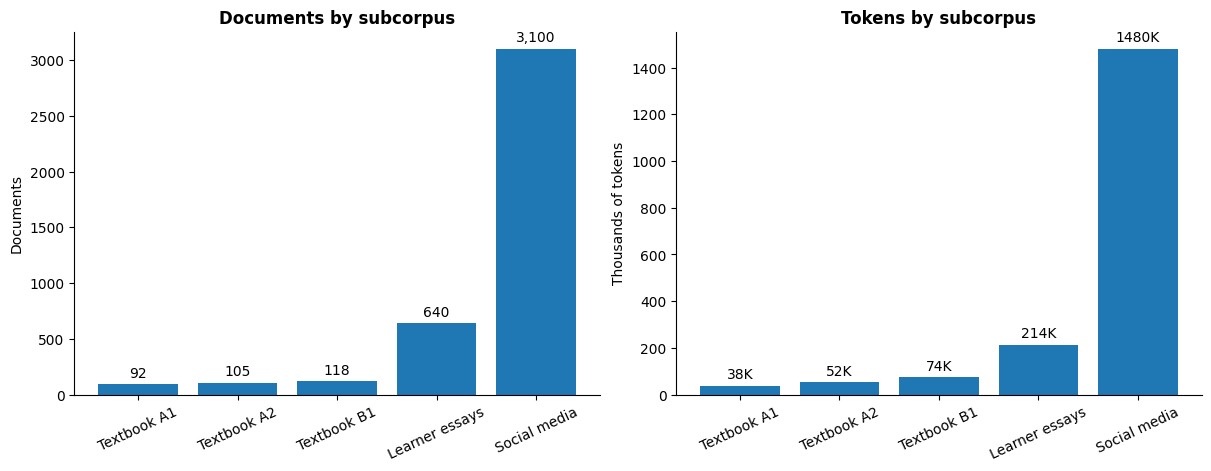

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")

doc_bars = axes[0].bar(corpus_summary["subcorpus"], corpus_summary["documents"])
axes[0].bar_label(doc_bars, padding=3, fmt="{:,.0f}")
axes[0].set(title="Documents by subcorpus", ylabel="Documents")
axes[0].tick_params(axis="x", rotation=25)

tok_bars = axes[1].bar(corpus_summary["subcorpus"], corpus_summary["tokens"] / 1_000)
axes[1].bar_label(tok_bars, padding=3, fmt="%.0fK")
axes[1].set(title="Tokens by subcorpus", ylabel="Thousands of tokens")
axes[1].tick_params(axis="x", rotation=25)

plt.show()

Plot both documents and tokens. A corpus can appear balanced by document count but highly imbalanced by token count.

## 2. Document-length distributions

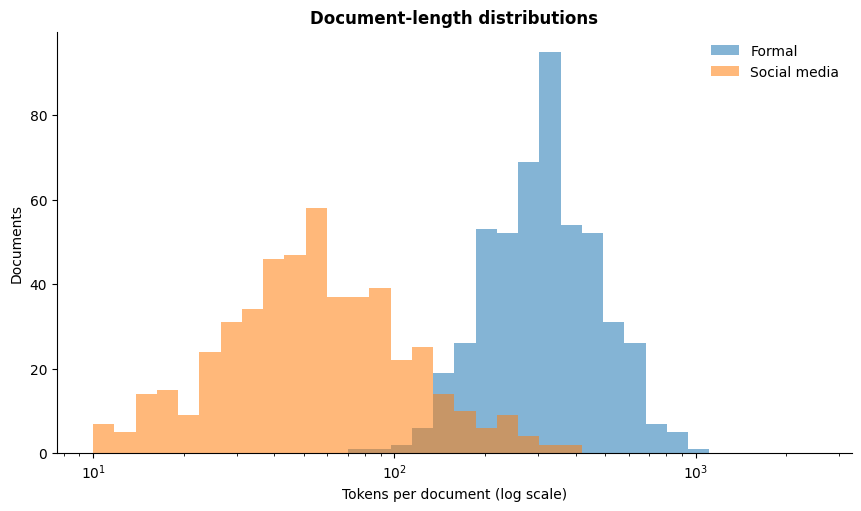

In [5]:
doc_lengths = pd.DataFrame({
    "tokens": np.concatenate([
        RNG.lognormal(5.8, 0.45, 500),
        RNG.lognormal(4.0, 0.75, 500),
    ]).astype(int),
    "source": ["Formal"] * 500 + ["Social media"] * 500,
})

fig, ax = plt.subplots(layout="constrained")
for source, group in doc_lengths.groupby("source"):
    ax.hist(
        group["tokens"],
        bins=np.geomspace(10, 2500, 35),
        alpha=0.55,
        label=source,
    )

ax.set_xscale("log")
ax.set(
    title="Document-length distributions",
    xlabel="Tokens per document (log scale)",
    ylabel="Documents",
)
ax.legend()
plt.show()

A log-scaled x-axis can reveal structure in highly skewed document lengths.  
Always state that the scale is logarithmic.

## 3. Sentence length by genre

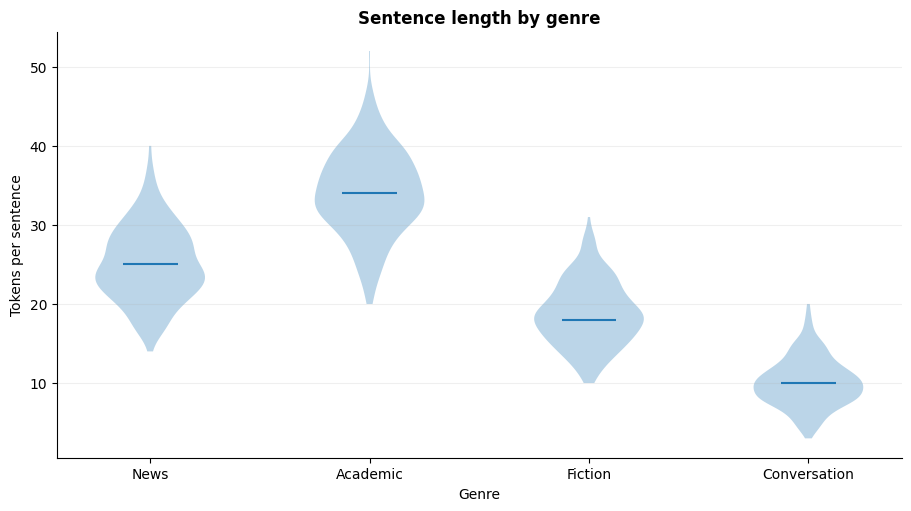

In [6]:
genres = ["News", "Academic", "Fiction", "Conversation"]
sentence_lengths = {
    "News": RNG.poisson(22, 450) + 3,
    "Academic": RNG.poisson(29, 450) + 5,
    "Fiction": RNG.poisson(17, 450) + 2,
    "Conversation": RNG.poisson(9, 450) + 1,
}

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
parts = ax.violinplot(
    [sentence_lengths[g] for g in genres],
    showmedians=True,
    showextrema=False,
)
ax.set(
    title="Sentence length by genre",
    xlabel="Genre",
    ylabel="Tokens per sentence",
    xticks=np.arange(1, len(genres) + 1),
    xticklabels=genres,
)
ax.grid(axis="y", alpha=0.2)
plt.show()

## 4. Word-frequency ranks and a Zipf plot

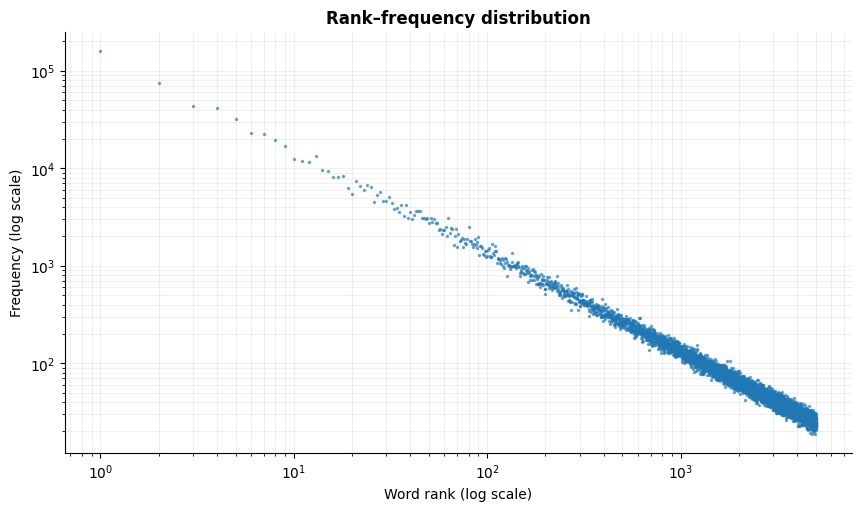

In [7]:
# Synthetic rank-frequency curve with noise.
rank = np.arange(1, 5001)
frequency = (160_000 / rank**1.03 * RNG.lognormal(0, 0.10, len(rank))).clip(1)

fig, ax = plt.subplots(layout="constrained")
ax.loglog(rank, frequency, ".", markersize=3, alpha=0.55)
ax.set(
    title="Rank–frequency distribution",
    xlabel="Word rank (log scale)",
    ylabel="Frequency (log scale)",
)
ax.grid(which="both", alpha=0.18)
plt.show()

A rank–frequency plot is useful for checking tokenization, normalization, and heavy-tailed frequency structure.  
Unexpected plateaus or isolated points can signal preprocessing artifacts.

## 5. Top tokens—filter before plotting

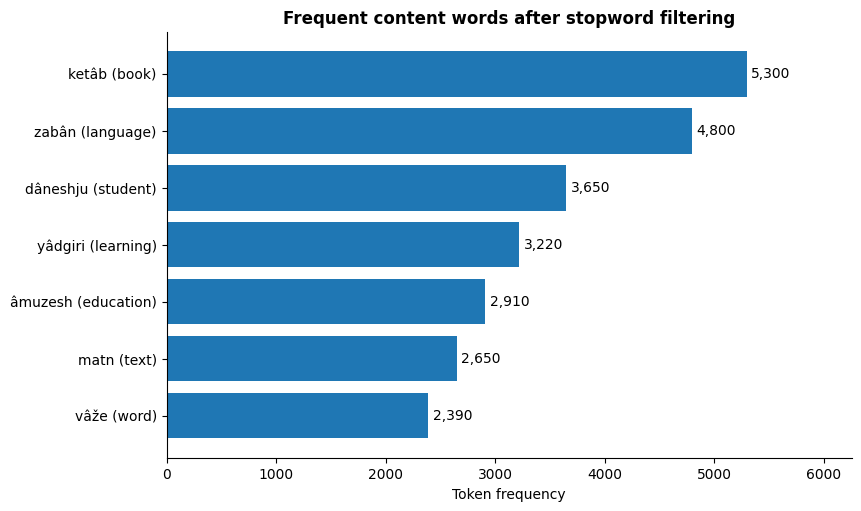

In [8]:
token_counts_fa = pd.Series({
    "و": 24100, "در": 18300, "به": 17100, "از": 14900, "که": 14200,
    "کتاب": 5300, "زبان": 4800, "دانشجو": 3650, "یادگیری": 3220,
    "آموزش": 2910, "متن": 2650, "واژه": 2390,
})

stopwords = {"و", "در", "به", "از", "که"}
content_counts = token_counts_fa.drop(labels=stopwords).sort_values().tail(10)

# Use shaped Persian when optional helpers exist; otherwise use readable transliterations.
fallback_labels = {
    "کتاب": "ketâb (book)",
    "زبان": "zabân (language)",
    "دانشجو": "dâneshju (student)",
    "یادگیری": "yâdgiri (learning)",
    "آموزش": "âmuzesh (education)",
    "متن": "matn (text)",
    "واژه": "vâže (word)",
}
display_labels = [
    rtl_text(token) if RTL_HELPERS_AVAILABLE else fallback_labels[token]
    for token in content_counts.index
]

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(display_labels, content_counts.values)
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set(
    title="Frequent content words after stopword filtering",
    xlabel="Token frequency",
    ylabel="",
)
ax.set_xlim(0, content_counts.max() * 1.18)
plt.show()

A “top words” chart is only meaningful after the tokenization, normalization, stopword, and unit decisions are explicit.

## 6. Vocabulary growth curves

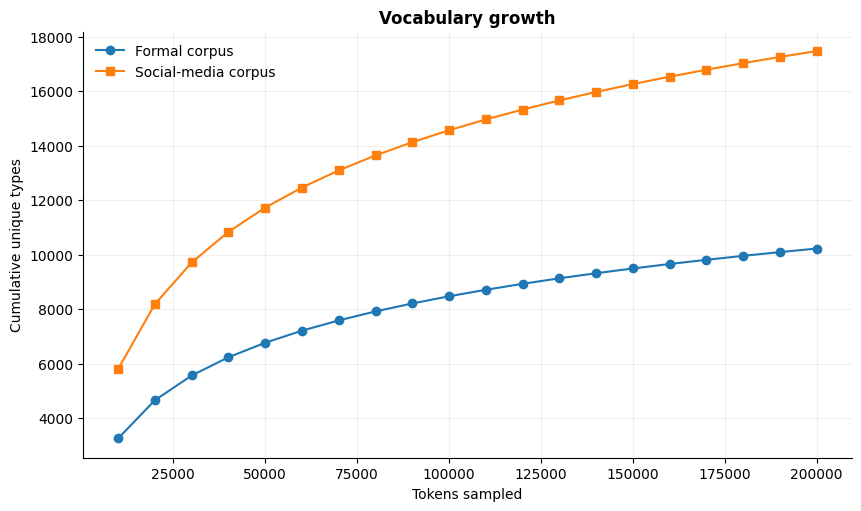

In [9]:
token_steps = np.arange(10_000, 210_000, 10_000)
formal_types = 2600 * np.log1p(token_steps / 4000)
social_types = 4300 * np.log1p(token_steps / 3500)

fig, ax = plt.subplots(layout="constrained")
ax.plot(token_steps, formal_types, marker="o", label="Formal corpus")
ax.plot(token_steps, social_types, marker="s", label="Social-media corpus")
ax.set(
    title="Vocabulary growth",
    xlabel="Tokens sampled",
    ylabel="Cumulative unique types",
)
ax.ticklabel_format(style="plain", axis="x")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

Vocabulary growth curves are more informative than a single type–token ratio because raw TTR decreases as sample size increases.

## 7. Lexical diversity with uncertainty

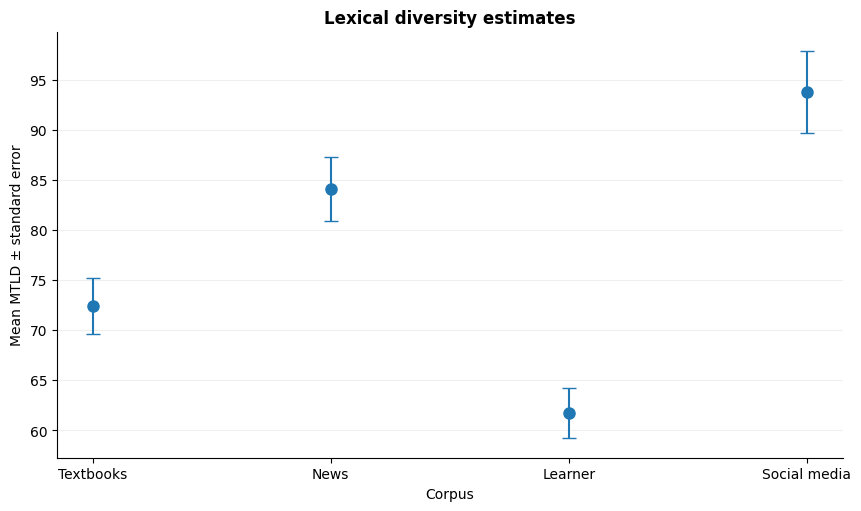

In [10]:
diversity = pd.DataFrame({
    "corpus": ["Textbooks", "News", "Learner", "Social media"],
    "mean_mtld": [72.4, 84.1, 61.7, 93.8],
    "se": [2.8, 3.2, 2.5, 4.1],
})

fig, ax = plt.subplots(layout="constrained")
ax.errorbar(
    diversity["corpus"],
    diversity["mean_mtld"],
    yerr=diversity["se"],
    fmt="o",
    capsize=5,
    markersize=8,
)
ax.set(
    title="Lexical diversity estimates",
    xlabel="Corpus",
    ylabel="Mean MTLD ± standard error",
)
ax.grid(axis="y", alpha=0.2)
plt.show()

Whenever possible, show uncertainty or variation rather than only point estimates.  
The correct interval depends on the sampling design and inferential goal.

## 8. POS distributions

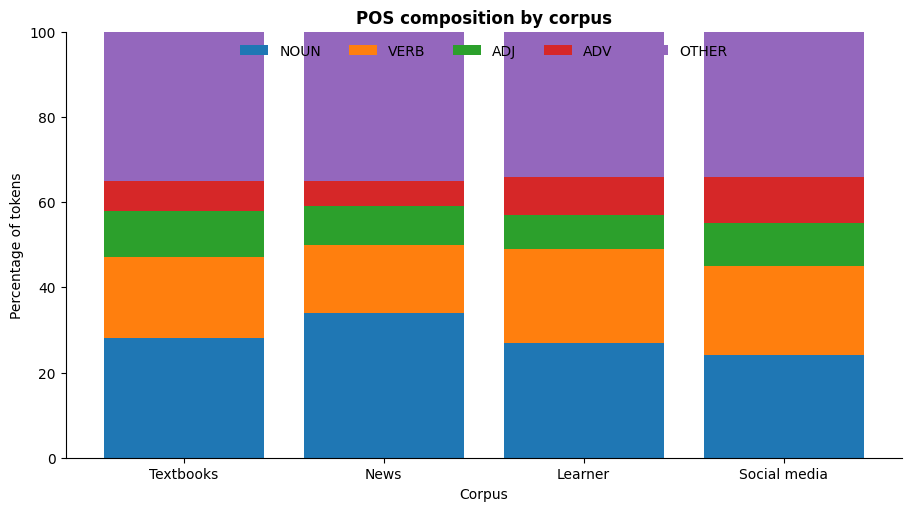

In [11]:
pos = pd.DataFrame({
    "genre": ["Textbooks", "News", "Learner", "Social media"],
    "NOUN": [28, 34, 27, 24],
    "VERB": [19, 16, 22, 21],
    "ADJ": [11, 9, 8, 10],
    "ADV": [7, 6, 9, 11],
    "OTHER": [35, 35, 34, 34],
}).set_index("genre")

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
bottom = np.zeros(len(pos))
for tag in pos.columns:
    ax.bar(pos.index, pos[tag], bottom=bottom, label=tag)
    bottom += pos[tag].to_numpy()

ax.set(
    title="POS composition by corpus",
    xlabel="Corpus",
    ylabel="Percentage of tokens",
    ylim=(0, 100),
)
ax.legend(ncols=5, loc="upper center")
plt.show()

A 100% stacked bar emphasizes composition. For precise comparisons of one tag across corpora, use grouped bars or a dot plot.

## 9. Annotation-label distribution and imbalance

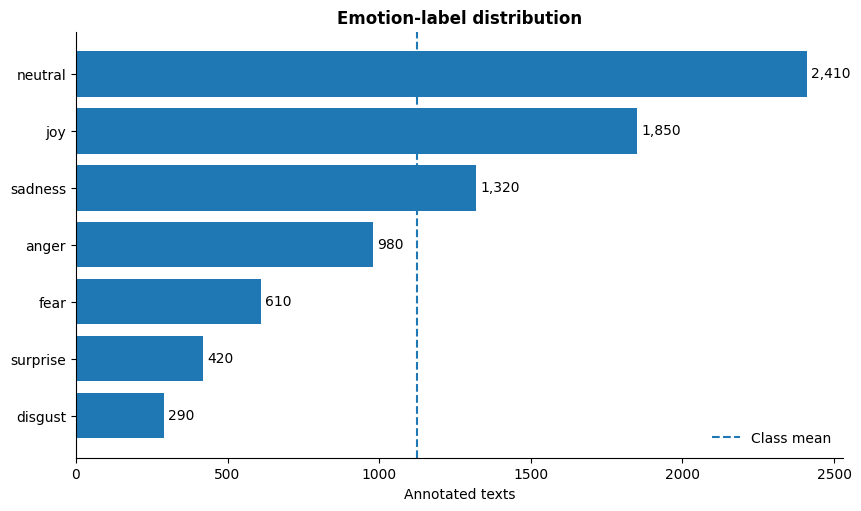

In [12]:
emotion_counts = pd.Series({
    "joy": 1850,
    "sadness": 1320,
    "anger": 980,
    "fear": 610,
    "surprise": 420,
    "disgust": 290,
    "neutral": 2410,
}).sort_values()

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(emotion_counts.index, emotion_counts.values)
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.axvline(emotion_counts.mean(), linestyle="--", label="Class mean")
ax.set(
    title="Emotion-label distribution",
    xlabel="Annotated texts",
    ylabel="",
)
ax.legend()
plt.show()

Class-imbalance figures help justify sampling, class weighting, stratification, and macro-averaged metrics.

## 10. Learner-error heatmap

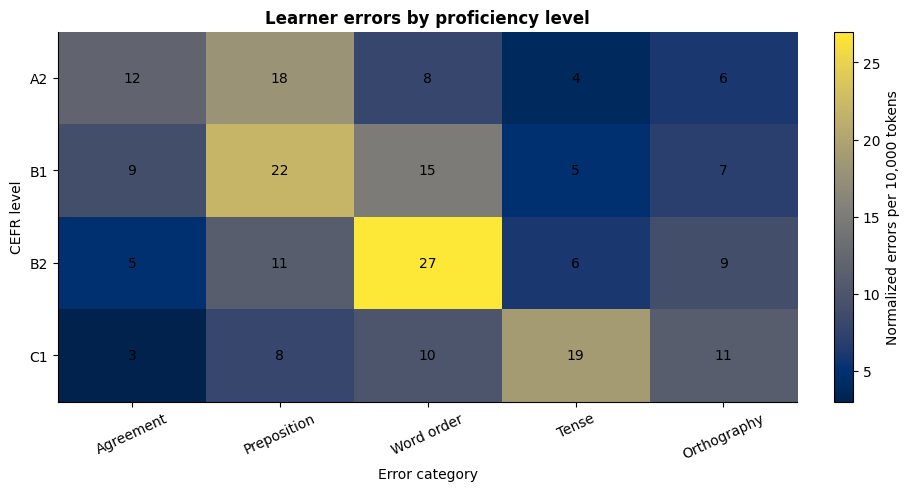

In [13]:
error_matrix = pd.DataFrame(
    [
        [12, 18, 8, 4, 6],
        [9, 22, 15, 5, 7],
        [5, 11, 27, 6, 9],
        [3, 8, 10, 19, 11],
    ],
    index=["A2", "B1", "B2", "C1"],
    columns=["Agreement", "Preposition", "Word order", "Tense", "Orthography"],
)

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
image = ax.imshow(error_matrix, cmap="cividis", aspect="auto")
ax.set(
    title="Learner errors by proficiency level",
    xlabel="Error category",
    ylabel="CEFR level",
    xticks=np.arange(error_matrix.shape[1]),
    xticklabels=error_matrix.columns,
    yticks=np.arange(error_matrix.shape[0]),
    yticklabels=error_matrix.index,
)
ax.tick_params(axis="x", rotation=25)

for row in range(error_matrix.shape[0]):
    for col in range(error_matrix.shape[1]):
        ax.text(col, row, error_matrix.iat[row, col],
                ha="center", va="center")

fig.colorbar(image, ax=ax, label="Normalized errors per 10,000 tokens")
plt.show()

Heatmaps are useful for two categorical dimensions. Include numeric labels when exact values matter.

## 11. Time trends in social-media corpora

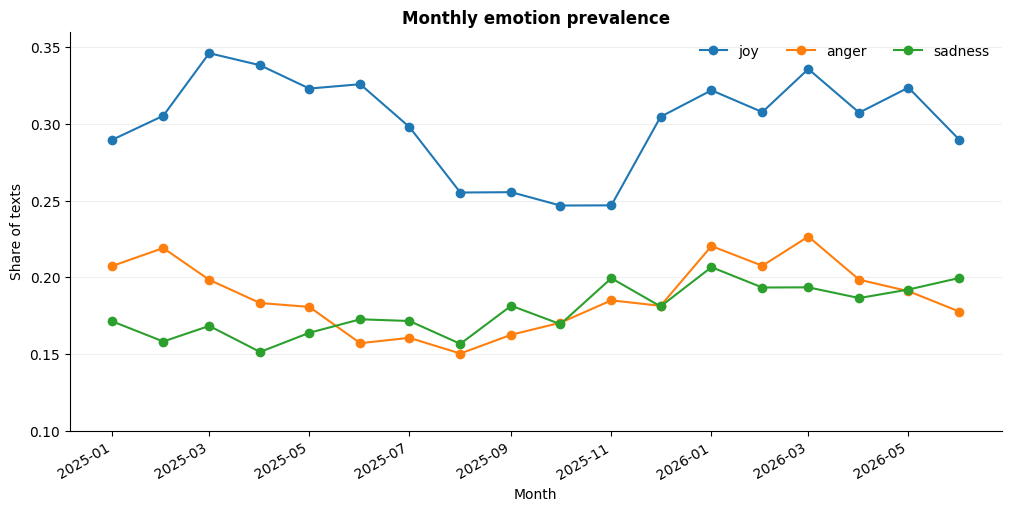

In [14]:
months = pd.date_range("2025-01-01", periods=18, freq="MS")
emotion_trends = pd.DataFrame({
    "date": months,
    "joy": 0.29 + 0.04 * np.sin(np.linspace(0, 3 * np.pi, len(months))) + RNG.normal(0, .012, len(months)),
    "anger": 0.18 + 0.03 * np.cos(np.linspace(0, 2.5 * np.pi, len(months))) + RNG.normal(0, .010, len(months)),
    "sadness": 0.16 + np.linspace(0, 0.035, len(months)) + RNG.normal(0, .010, len(months)),
})

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
for label in ["joy", "anger", "sadness"]:
    ax.plot(emotion_trends["date"], emotion_trends[label], marker="o", label=label)

ax.set(
    title="Monthly emotion prevalence",
    xlabel="Month",
    ylabel="Share of texts",
    ylim=(0.10, 0.36),
)
ax.legend(ncols=3)
ax.grid(axis="y", alpha=0.2)
fig.autofmt_xdate()
plt.show()

For temporal corpora, distinguish real prevalence change from changes in sampling, platform activity, topic mixture, and annotation practice.

## 12. Small multiples for comparable trends

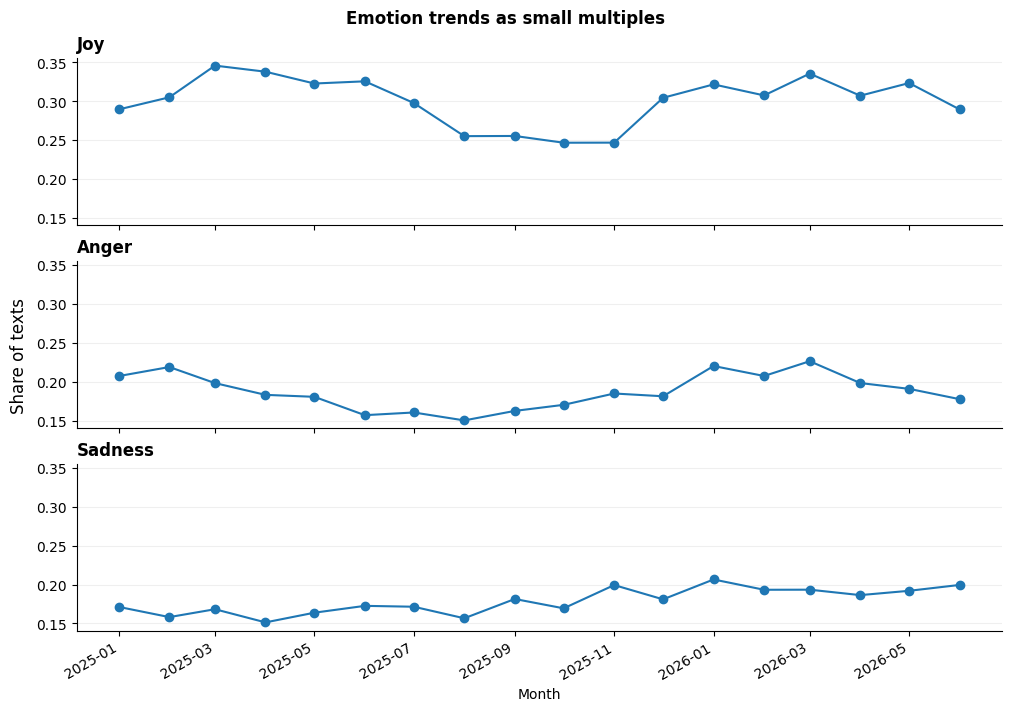

In [15]:
labels = ["joy", "anger", "sadness"]
fig, axes = plt.subplots(len(labels), 1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained")

for ax, label in zip(axes, labels):
    ax.plot(emotion_trends["date"], emotion_trends[label], marker="o")
    ax.set_title(label.capitalize(), loc="left")
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("Month")
fig.supylabel("Share of texts")
fig.suptitle("Emotion trends as small multiples", fontweight="bold")
fig.autofmt_xdate()
plt.show()

Small multiples reduce overlap and make within-series patterns easier to inspect. Use shared axes when comparisons require a common scale.

## 13. Metaphor annotation by domain

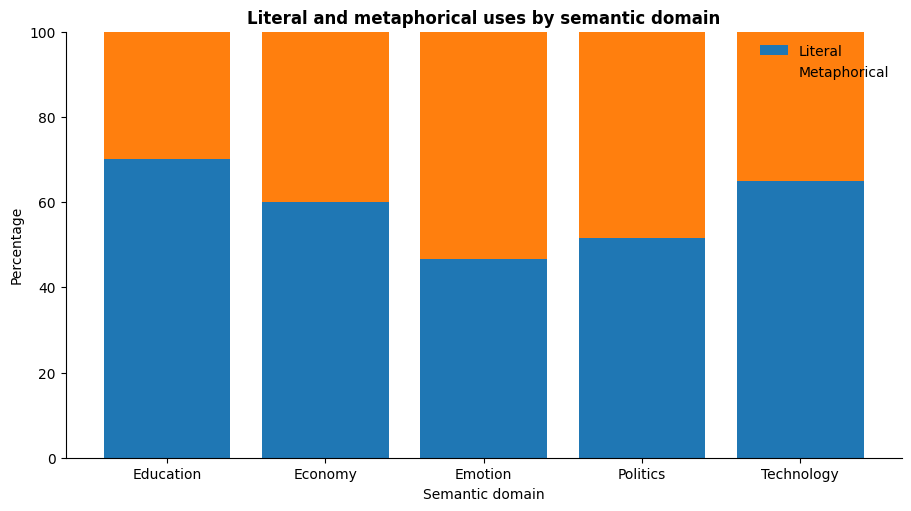

In [16]:
metaphor = pd.DataFrame({
    "domain": ["Education", "Economy", "Emotion", "Politics", "Technology"],
    "literal": [420, 360, 280, 310, 390],
    "metaphorical": [180, 240, 320, 290, 210],
}).set_index("domain")

metaphor_pct = metaphor.div(metaphor.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
bottom = np.zeros(len(metaphor_pct))
for label in ["literal", "metaphorical"]:
    ax.bar(metaphor_pct.index, metaphor_pct[label], bottom=bottom, label=label.capitalize())
    bottom += metaphor_pct[label].to_numpy()

ax.set(
    title="Literal and metaphorical uses by semantic domain",
    xlabel="Semantic domain",
    ylabel="Percentage",
    ylim=(0, 100),
)
ax.legend()
plt.show()

## 14. Concordance-style visualization

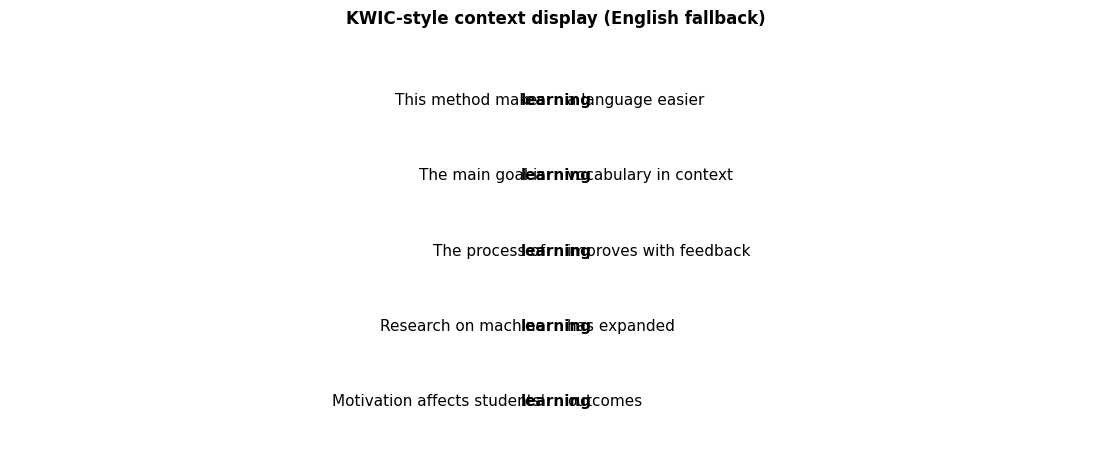

In [17]:
contexts_fa = [
    ("این روش", "یادگیری", "زبان را آسان‌تر می‌کند"),
    ("هدف اصلی", "یادگیری", "واژگان در بافت است"),
    ("فرایند", "یادگیری", "با بازخورد بهتر می‌شود"),
    ("پژوهش درباره", "یادگیری", "ماشینی گسترش یافته است"),
    ("انگیزه بر", "یادگیری", "دانشجویان اثر می‌گذارد"),
]
contexts_en = [
    ("This method makes", "learning", "a language easier"),
    ("The main goal is", "learning", "vocabulary in context"),
    ("The process of", "learning", "improves with feedback"),
    ("Research on machine", "learning", "has expanded"),
    ("Motivation affects students'", "learning", "outcomes"),
]

if RTL_HELPERS_AVAILABLE:
    contexts = [
        tuple(rtl_text(part) for part in context)
        for context in contexts_fa
    ]
    title = rtl_text("نمایش بافت کلیدواژه")
else:
    contexts = contexts_en
    title = "KWIC-style context display (English fallback)"

fig, ax = plt.subplots(figsize=(11, 4.6), layout="constrained")
ax.set_xlim(-1, 1)
ax.set_ylim(-0.8, len(contexts) - 0.2)
ax.axis("off")

for row, (left, keyword, right) in enumerate(reversed(contexts)):
    ax.text(-0.02, row, left, ha="right", va="center", fontsize=11)
    ax.text(0, row, keyword, ha="center", va="center",
            fontsize=11, fontweight="bold")
    ax.text(0.02, row, right, ha="left", va="center", fontsize=11)

ax.set_title(title, pad=12)
plt.show()

This is a compact visual analogue of a KWIC table. For large concordances, use a dataframe or specialized corpus interface instead of plotting every row.

## 15. Persian and right-to-left text

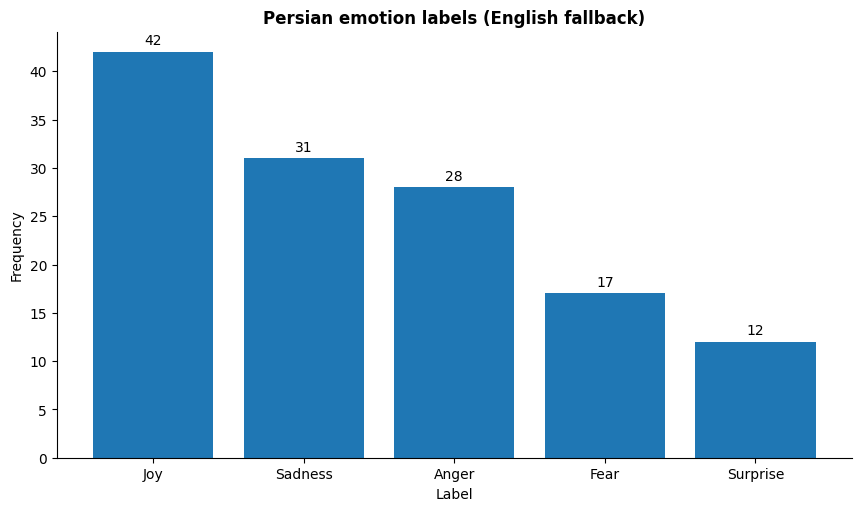

In [18]:
raw_labels = ["شادی", "غم", "خشم", "ترس", "تعجب"]
english_fallback = ["Joy", "Sadness", "Anger", "Fear", "Surprise"]
values = [42, 31, 28, 17, 12]

if RTL_HELPERS_AVAILABLE:
    display_labels = [rtl_text(label) for label in raw_labels]
    title = rtl_text("توزیع برچسب‌های هیجان")
    xlabel = rtl_text("برچسب")
    ylabel = rtl_text("فراوانی")
else:
    display_labels = english_fallback
    title = "Persian emotion labels (English fallback)"
    xlabel = "Label"
    ylabel = "Frequency"

fig, ax = plt.subplots(layout="constrained")
bars = ax.bar(display_labels, values)
ax.bar_label(bars, padding=3)
ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
plt.show()

Modern environments may display Persian correctly without extra packages, but shaping and bidirectional rendering vary by backend and font.

For a more reliable fallback:

```text
pip install arabic-reshaper python-bidi
```

Also choose a font installed on the target machine that contains Persian glyphs.  
Do not bundle proprietary font files in the repository.

## 16. A reusable corpus-profile function

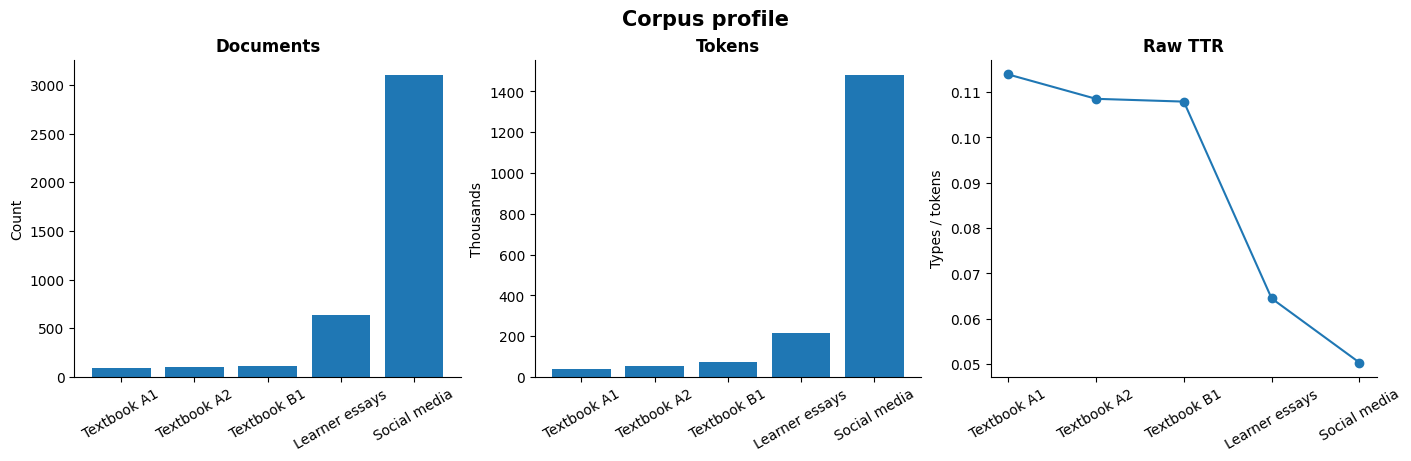

In [19]:
def plot_corpus_profile(summary: pd.DataFrame):
    """Create a three-panel profile from subcorpus summary statistics."""
    required = {"subcorpus", "documents", "tokens", "types"}
    missing = required.difference(summary.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")

    axes[0].bar(summary["subcorpus"], summary["documents"])
    axes[0].set(title="Documents", ylabel="Count")

    axes[1].bar(summary["subcorpus"], summary["tokens"] / 1_000)
    axes[1].set(title="Tokens", ylabel="Thousands")

    ttr = summary["types"] / summary["tokens"]
    axes[2].plot(summary["subcorpus"], ttr, marker="o")
    axes[2].set(title="Raw TTR", ylabel="Types / tokens")

    for ax in axes:
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Corpus profile", fontsize=15, fontweight="bold")
    return fig, axes


fig, axes = plot_corpus_profile(corpus_summary)
plt.show()

Raw TTR is included here only to demonstrate plotting. Do not compare raw TTR across corpora of very different sizes without controlling sample size.

## 17. Exploratory visualization checklist

Before interpreting a corpus plot, ask:

1. What is the unit—tokens, types, documents, users, sentences, or annotations?
2. Are counts raw, normalized, or percentages?
3. Are corpus sizes comparable?
4. Did tokenization and normalization change the distribution?
5. Are rare categories hidden by aggregation?
6. Does the graph display uncertainty or sample variation?
7. Are category orders meaningful?
8. Are log scales, filtering, and exclusions stated?
9. Does the chart remain readable with long Persian labels?
10. Can another researcher reproduce it from code and data?

## 18. Exercises and mini-project prompts

1. From `corpus_summary`, calculate tokens per document and plot the values as sorted horizontal bars.
2. Build a two-panel comparison of raw token counts and normalized rates per 10,000 tokens.
3. Create a Zipf plot for two alternative tokenization pipelines and explain any divergence.
4. Plot learner-error rates by proficiency level as an annotated heatmap.
5. Visualize emotion prevalence across time using proportions rather than raw counts.
6. Design a corpus-balance dashboard that contains at least three panels and one written interpretation.


## 19. Reference solutions

The solutions reuse or generate small synthetic data so the notebook remains fully reproducible.


### Solution 1 — tokens per document


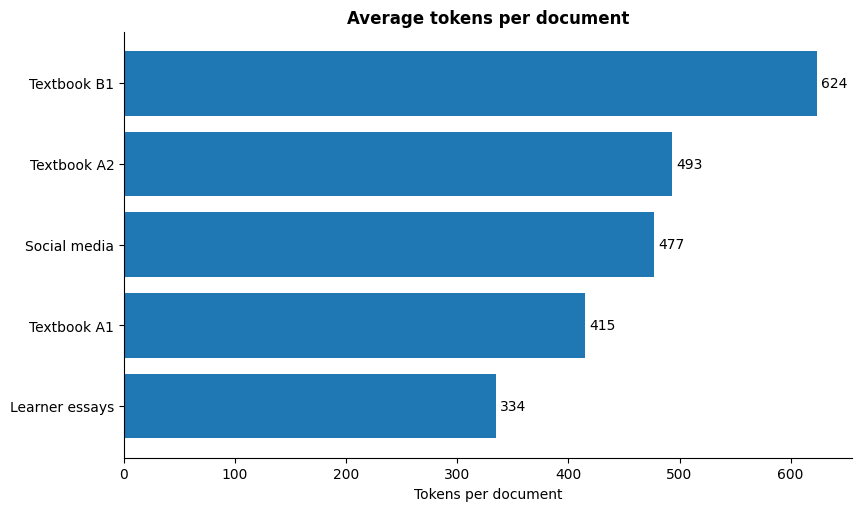

In [20]:
tokens_per_document = (
    corpus_summary.set_index("subcorpus")["tokens"]
    / corpus_summary.set_index("subcorpus")["documents"]
).sort_values()

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(tokens_per_document.index, tokens_per_document.values)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(title="Average tokens per document", xlabel="Tokens per document", ylabel="")
plt.show()


### Solution 2 — raw counts versus normalized rates


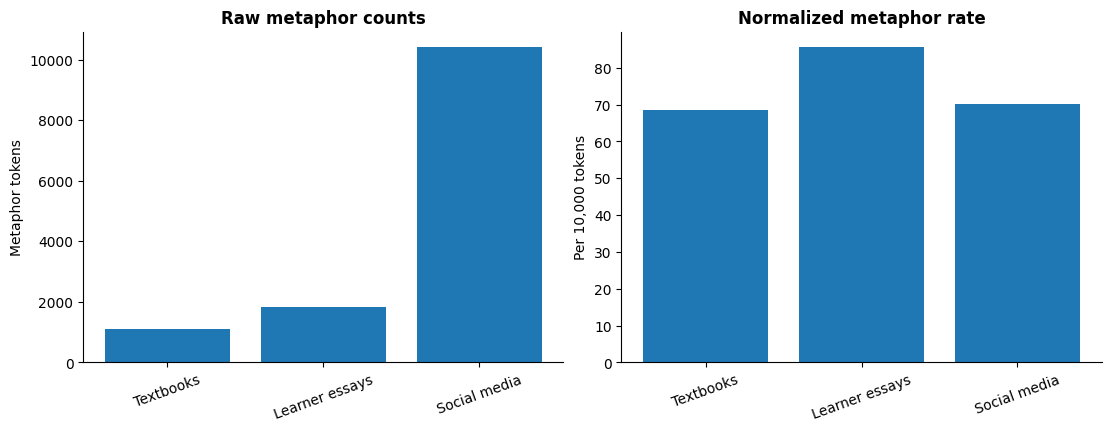

In [21]:
normalization_example = pd.DataFrame({
    "subcorpus": ["Textbooks", "Learner essays", "Social media"],
    "tokens": [163_600, 214_000, 1_480_000],
    "metaphors": [1_120, 1_830, 10_400],
})
normalization_example["per_10k"] = (
    normalization_example["metaphors"] / normalization_example["tokens"] * 10_000
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].bar(normalization_example["subcorpus"], normalization_example["metaphors"])
axes[0].set(title="Raw metaphor counts", ylabel="Metaphor tokens")
axes[1].bar(normalization_example["subcorpus"], normalization_example["per_10k"])
axes[1].set(title="Normalized metaphor rate", ylabel="Per 10,000 tokens")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.show()


### Solution 3 — compare tokenization pipelines with Zipf plots


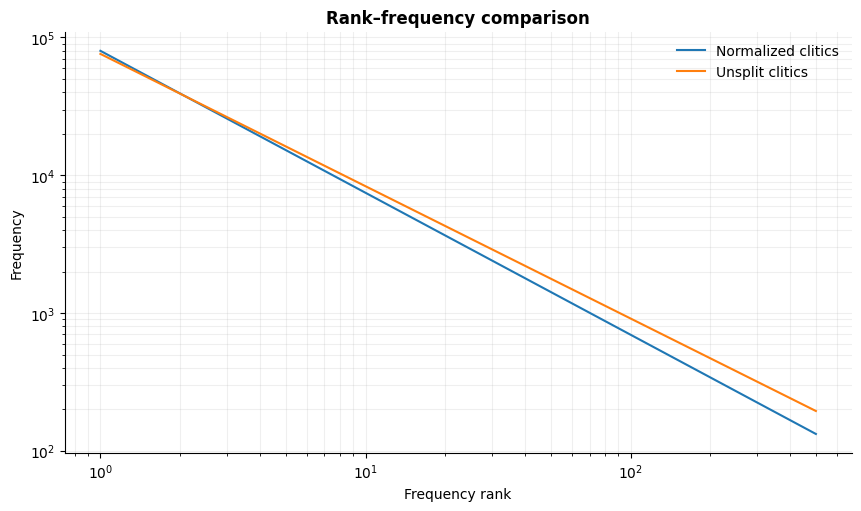

In [22]:
ranks = np.arange(1, 501)
pipeline_a = 80_000 / ranks ** 1.03
pipeline_b = 76_000 / ranks ** 0.96

fig, ax = plt.subplots(layout="constrained")
ax.loglog(ranks, pipeline_a, label="Normalized clitics")
ax.loglog(ranks, pipeline_b, label="Unsplit clitics")
ax.set(title="Rank–frequency comparison", xlabel="Frequency rank", ylabel="Frequency")
ax.legend()
ax.grid(alpha=0.2, which="both")
plt.show()


### Solution 4 — learner-error heatmap


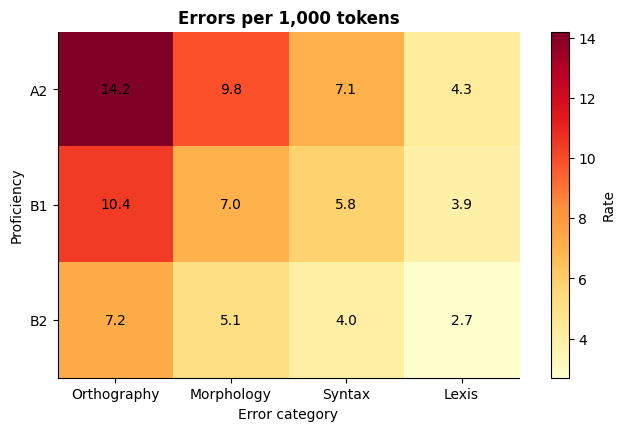

In [23]:
solution_error_matrix = pd.DataFrame(
    [[14.2, 9.8, 7.1, 4.3], [10.4, 7.0, 5.8, 3.9], [7.2, 5.1, 4.0, 2.7]],
    index=["A2", "B1", "B2"],
    columns=["Orthography", "Morphology", "Syntax", "Lexis"],
)

fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
im = ax.imshow(solution_error_matrix, cmap="YlOrRd")
ax.set(
    title="Errors per 1,000 tokens",
    xlabel="Error category",
    ylabel="Proficiency",
    xticks=np.arange(len(solution_error_matrix.columns)),
    xticklabels=solution_error_matrix.columns,
    yticks=np.arange(len(solution_error_matrix.index)),
    yticklabels=solution_error_matrix.index,
)
for i in range(solution_error_matrix.shape[0]):
    for j in range(solution_error_matrix.shape[1]):
        ax.text(j, i, f"{solution_error_matrix.iloc[i, j]:.1f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Rate")
plt.show()


### Solution 5 — emotion proportions across time


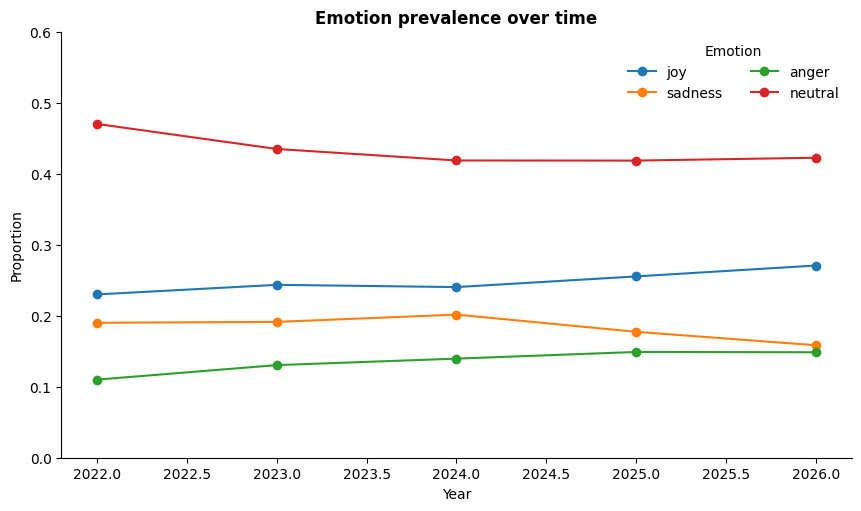

In [24]:
emotion_by_year = pd.DataFrame({
    "year": [2022, 2023, 2024, 2025, 2026],
    "joy": [230, 280, 310, 360, 410],
    "sadness": [190, 220, 260, 250, 240],
    "anger": [110, 150, 180, 210, 225],
    "neutral": [470, 500, 540, 590, 640],
}).set_index("year")
emotion_prop = emotion_by_year.div(emotion_by_year.sum(axis=1), axis=0)

fig, ax = plt.subplots(layout="constrained")
emotion_prop.plot(marker="o", ax=ax)
ax.set(title="Emotion prevalence over time", xlabel="Year", ylabel="Proportion", ylim=(0, 0.6))
ax.legend(title="Emotion", ncols=2)
plt.show()


### Solution 6 — compact corpus-balance dashboard


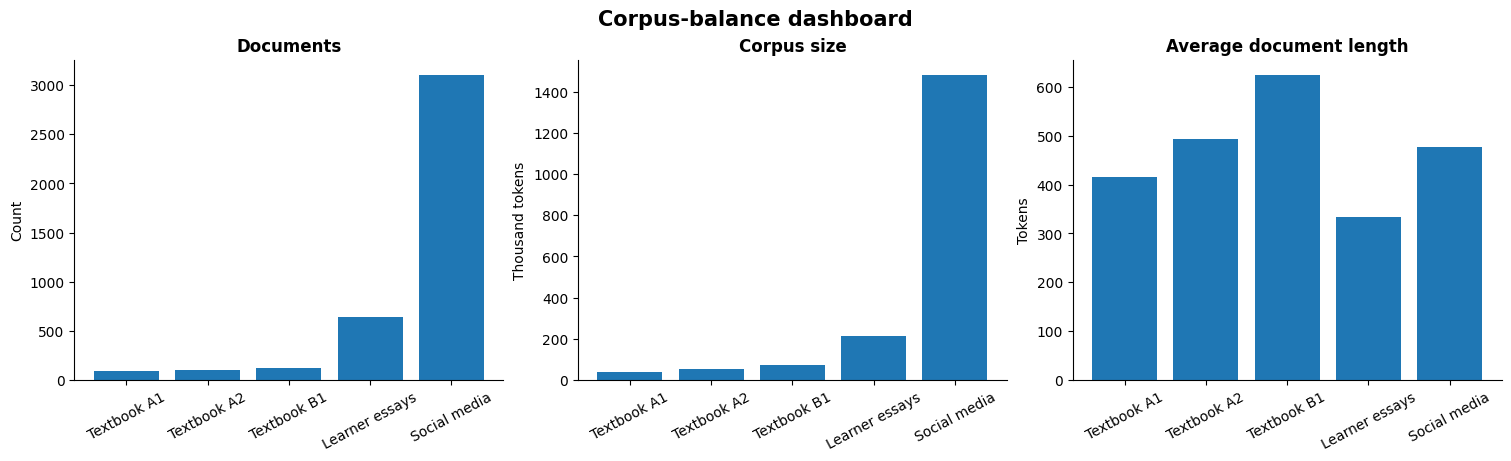

In [25]:
dashboard = corpus_summary.copy()
dashboard["tokens_per_document"] = dashboard["tokens"] / dashboard["documents"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
axes[0].bar(dashboard["subcorpus"], dashboard["documents"])
axes[0].set(title="Documents", ylabel="Count")
axes[1].bar(dashboard["subcorpus"], dashboard["tokens"] / 1_000)
axes[1].set(title="Corpus size", ylabel="Thousand tokens")
axes[2].bar(dashboard["subcorpus"], dashboard["tokens_per_document"])
axes[2].set(title="Average document length", ylabel="Tokens")
for ax in axes:
    ax.tick_params(axis="x", rotation=28)
fig.suptitle("Corpus-balance dashboard", fontsize=15, fontweight="bold")
plt.show()


**Interpretation example:** The social-media subcorpus dominates total token count and document count, while the smaller pedagogical subcorpora contain longer and more controlled documents. Any pooled analysis should therefore report subcorpus-specific results or apply an explicit sampling strategy.


## 20. References

- Matplotlib quick start: https://matplotlib.org/stable/users/explain/quick_start.html
- Histograms: https://matplotlib.org/stable/gallery/statistics/hist.html
- Image/heatmap examples: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
- Colormap guidance: https://matplotlib.org/stable/users/explain/colors/colormaps.html
- Text properties and layout: https://matplotlib.org/stable/users/explain/text/text_props.html
